In [6]:
# Robodesk
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
color_list = sns.color_palette()
def plot_csv_files(directory_path, taskname, column_name=['x', 'y1', 'y2', 'y3']):
    files = os.listdir(directory_path)
    fig_width = 6.4
    fig_height = 4.8
    scale = 1.3
    plt.figure(figsize=(fig_width * scale, fig_height * scale))
    for file in files:
        if  file.endswith('.csv'):
            if file == 'IFactor.csv':
                file_path = os.path.join(directory_path, file)
                data = pd.read_csv(file_path, names=column_name)
                data['x'] = data['x']
                mean = data[column_name[1:]].mean(axis=1)
                std = data[column_name[1:]].std(axis=1)
                plt.plot(data['x'], mean, label='IFactor w/o MI', linewidth=2)
                plt.fill_between(data['x'], mean - std, mean + std, alpha=0.2)
            elif file == 'IFactor_01.csv':
                file_path = os.path.join(directory_path, file)
                data = pd.read_csv(file_path, names=column_name)
                data['x'] = data['x']
                mean = data[column_name[1:]].mean(axis=1)
                std = data[column_name[1:]].std(axis=1)
                plt.plot(data['x'], mean, label='IFactor', linewidth=2)
                plt.fill_between(data['x'], mean - std, mean + std, alpha=0.2)
                
                # sns.lineplot(data=data, x='x', y='y', label="InterpRL", linewidth=3)
    plt.axhline(y=240, linestyle='dashed', label='DenoisedMDP', linewidth=2, color=color_list[5])
    fname = os.path.join(directory_path, f"{taskname}.pdf")
    plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    plt.title('Reacher+Video+CameraJittering', fontsize=24)
    plt.xlabel('Environment Steps', fontsize=22)
    plt.ylabel('Episode Return', fontsize=22)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(loc='upper left', fontsize=15)
    # plt.show()
    plt.savefig(fname)


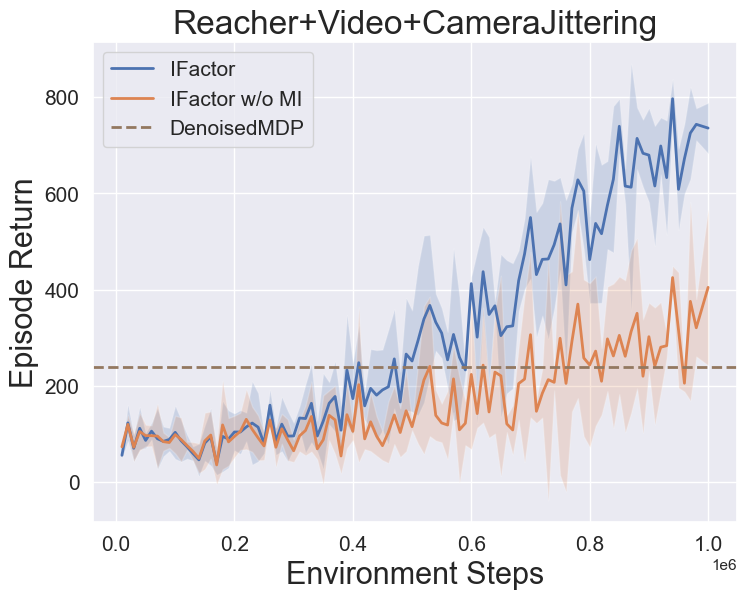

In [7]:

# Robodesk
directory_path = 'anonymized_path'
plot_csv_files(directory_path, column_name=['x', 'y1', 'y2', 'y3'], taskname='robodesk')